### Read Data

In [1]:
# import liabaray
import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# delete warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# read data
data=pd.read_csv('/kaggle/input/prad-mcspc-mskcc-2020-clinical-data/prad_mcspc_mskcc_2020_clinical_data.tsv',delimiter='\t')

In [4]:
class_names = ["high volume", "low volume"]

In [5]:
# show first 5 row of data
data.head()

,Study ID,Patient ID,Sample ID,Age at Sample Collection,Androgen Deprivation Therapy (ADT),Archer Panel,Biopsy Gleason Grade,Cancer Type,Cancer Type Detailed,Timing of metastases,...,Number of Samples Per Patient,Sample coverage,Sex,Time from sample to castration resistance [months],Somatic Status,SO comments,Survival Status,Tissue Site,TMB (nonsynonymous),Tumor Purity
0,prad_mcspc_mskcc_2020,P-0000373,P-0000373-T01-IM3,55,No,NO,9-10,Prostate Cancer,Prostate Adenocarcinoma,De-novo metastatic,...,1,708,Male,20.03,Matched,NaN,Dead,Lymph Node,1.109155,60.0
1,prad_mcspc_mskcc_2020,P-0000431,P-0000431-T01-IM3,57,Yes,NO,8,Prostate Cancer,Prostate Adenocarcinoma,De-novo metastatic,...,1,530,Male,35.58,Matched,NaN,Alive,Lymph Node,1.109155,60.0
2,prad_mcspc_mskcc_2020,P-0000442,P-0000442-T01-IM3,67,No,NO,8,Prostate Cancer,Prostate Adenocarcinoma,De-novo metastatic,...,1,922,Male,56.29,Matched,NaN,Alive,Prostate,1.109155,50.0
3,prad_mcspc_mskcc_2020,P-0000509,P-0000509-T01-IM3,64,Yes,NO,9-10,Prostate Cancer,Prostate Adenocarcinoma,De-novo metastatic,...,1,651,Male,39.84,Matched,NaN,Alive,Prostate,2.218311,50.0
4,prad_mcspc_mskcc_2020,P-0000541,P-0000541-T01-IM3,57,Yes,NO,9-10,Prostate Cancer,Prostate Adenocarcinoma,De-novo metastatic,...,1,515,Male,21.58,Matched,NaN,Dead,Prostate,3.327466,60.0


### Data Exploration

In [6]:
# display columns name
data.columns

Index(['Study ID', 'Patient ID', 'Sample ID', 'Age at Sample Collection',
       'Androgen Deprivation Therapy (ADT)', 'Archer Panel',
       'Biopsy Gleason Grade', 'Cancer Type', 'Cancer Type Detailed',
       'Timing of metastases', 'Disease Extent', 'Disease volume',
       'Fraction Genome Altered', 'Gene Panel', 'Institute Source',
       'Castration Resistance Event', 'MSI Comment', 'MSI Score', 'MSI Type',
       'MSK Slide ID', 'Mutation Count', 'Oncotree Code',
       'Overall Survival since Sample Collection (Months)',
       '12-245 Part A Consented', '12-245 Part C Consented',
       'MSK Pathology Slide Available', 'Pediatric Case Indicator',
       'Prostate-specific antigen', 'Race Category', 'Sample Class',
       'Number of Samples Per Patient', 'Sample coverage', 'Sex',
       'Time from sample to castration resistance [months]', 'Somatic Status',
       'SO comments', 'Survival Status', 'Tissue Site', 'TMB (nonsynonymous)',
       'Tumor Purity'],
      dtype='objec

In [7]:
# display information about data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 40 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Study ID                                            424 non-null    object 
 1   Patient ID                                          424 non-null    object 
 2   Sample ID                                           424 non-null    object 
 3   Age at Sample Collection                            424 non-null    object 
 4   Androgen Deprivation Therapy (ADT)                  421 non-null    object 
 5   Archer Panel                                        424 non-null    object 
 6   Biopsy Gleason Grade                                384 non-null    object 
 7   Cancer Type                                         424 non-null    object 
 8   Cancer Type Detailed                                424 non-null    object 
 9  

In [8]:
# show discribe about data
data.describe(include='all')

,Study ID,Patient ID,Sample ID,Age at Sample Collection,Androgen Deprivation Therapy (ADT),Archer Panel,Biopsy Gleason Grade,Cancer Type,Cancer Type Detailed,Timing of metastases,...,Number of Samples Per Patient,Sample coverage,Sex,Time from sample to castration resistance [months],Somatic Status,SO comments,Survival Status,Tissue Site,TMB (nonsynonymous),Tumor Purity
count,424,424,424,424,421,424,384,424,424,424,...,424.0,424.000000,424,424.000000,424,132,424,424,424.000000,419.000000
unique,1,424,424,43,2,2,6,1,1,2,...,NaN,NaN,1,NaN,1,71,2,6,NaN,NaN
top,prad_mcspc_mskcc_2020,P-0000373,P-0000373-T01-IM3,66,No,NO,9-10,Prostate Cancer,Prostate Adenocarcinoma,De-novo metastatic,...,NaN,NaN,Male,NaN,Matched,NANote: Low tumor content (approximately 20% o...,Alive,Prostate,NaN,NaN
freq,424,1,1,24,330,413,191,424,424,275,...,NaN,NaN,424,NaN,424,30,322,204,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,683.198113,NaN,17.883561,NaN,NaN,NaN,NaN,4.026720,40.477327
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,229.952166,NaN,18.147651,NaN,NaN,NaN,NaN,7.179191,20.583854
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,103.000000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,542.500000,NaN,6.222500,NaN,NaN,NaN,NaN,1.729396,20.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,698.000000,NaN,12.690000,NaN,NaN,NaN,NaN,2.594094,40.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,850.000000,NaN,23.000000,NaN,NaN,NaN,NaN,3.914879,60.000000


In [9]:
# check missing values
data.isnull().sum()

Study ID                                                0
Patient ID                                              0
Sample ID                                               0
Age at Sample Collection                                0
Androgen Deprivation Therapy (ADT)                      3
Archer Panel                                            0
Biopsy Gleason Grade                                   40
Cancer Type                                             0
Cancer Type Detailed                                    0
Timing of metastases                                    0
Disease Extent                                          0
Disease volume                                          0
Fraction Genome Altered                                 0
Gene Panel                                              0
Institute Source                                        0
Castration Resistance Event                             0
MSI Comment                                           203
MSI Score     

In [10]:
# check duplicated
data.duplicated().sum()

0

### Data Preprocessing and Data Visualization

In [11]:
# drop non important columns
data.drop(["Study ID", "Patient ID", "Sample ID","MSK Slide ID",
           "SO comments", "Cancer Type", "Cancer Type Detailed", "Race Category"], axis = 1 , inplace = True)

In [12]:
data.head()

,Age at Sample Collection,Androgen Deprivation Therapy (ADT),Archer Panel,Biopsy Gleason Grade,Timing of metastases,Disease Extent,Disease volume,Fraction Genome Altered,Gene Panel,Institute Source,...,Sample Class,Number of Samples Per Patient,Sample coverage,Sex,Time from sample to castration resistance [months],Somatic Status,Survival Status,Tissue Site,TMB (nonsynonymous),Tumor Purity
0,55,No,NO,9-10,De-novo metastatic,Metastatic hormone-sensitive,Low-volume disease,0.0023,IMPACT341,MSKCC,...,Tumor,1,708,Male,20.03,Matched,Dead,Lymph Node,1.109155,60.0
1,57,Yes,NO,8,De-novo metastatic,Metastatic hormone-sensitive,Low-volume disease,0.1985,IMPACT341,MSKCC,...,Tumor,1,530,Male,35.58,Matched,Alive,Lymph Node,1.109155,60.0
2,67,No,NO,8,De-novo metastatic,Metastatic hormone-sensitive,High-volume disease,0.1419,IMPACT341,MSKCC,...,Tumor,1,922,Male,56.29,Matched,Alive,Prostate,1.109155,50.0
3,64,Yes,NO,9-10,De-novo metastatic,Metastatic hormone-sensitive,Low-volume disease,0.0161,IMPACT341,MSKCC,...,Tumor,1,651,Male,39.84,Matched,Alive,Prostate,2.218311,50.0
4,57,Yes,NO,9-10,De-novo metastatic,Metastatic hormone-sensitive,Low-volume disease,0.3134,IMPACT341,MSKCC,...,Tumor,1,515,Male,21.58,Matched,Dead,Prostate,3.327466,60.0


In [13]:
# categorical column
categorical=[]
for i in data.columns:
    if data[i].dtype=='object':
      categorical.append(i)
print(categorical)

['Age at Sample Collection', 'Androgen Deprivation Therapy (ADT)', 'Archer Panel', 'Biopsy Gleason Grade', 'Timing of metastases', 'Disease Extent', 'Disease volume', 'Gene Panel', 'Institute Source', 'Castration Resistance Event', 'MSI Comment', 'MSI Type', 'Oncotree Code', '12-245 Part A Consented', '12-245 Part C Consented', 'MSK Pathology Slide Available', 'Pediatric Case Indicator', 'Sample Class', 'Sex', 'Somatic Status', 'Survival Status', 'Tissue Site']


In [14]:
data[categorical].isnull().sum()

Age at Sample Collection                0
Androgen Deprivation Therapy (ADT)      3
Archer Panel                            0
Biopsy Gleason Grade                   40
Timing of metastases                    0
Disease Extent                          0
Disease volume                          0
Gene Panel                              0
Institute Source                        0
Castration Resistance Event             0
MSI Comment                           203
MSI Type                                0
Oncotree Code                           0
12-245 Part A Consented                 0
12-245 Part C Consented                 0
MSK Pathology Slide Available           0
Pediatric Case Indicator                0
Sample Class                            0
Sex                                     0
Somatic Status                          0
Survival Status                         0
Tissue Site                             0
dtype: int64

In [15]:
# handle missing values in categorical column
data[categorical]=data[categorical].fillna(data[categorical].mode().iloc[0])

In [16]:
data[categorical].isnull().sum()

Age at Sample Collection              0
Androgen Deprivation Therapy (ADT)    0
Archer Panel                          0
Biopsy Gleason Grade                  0
Timing of metastases                  0
Disease Extent                        0
Disease volume                        0
Gene Panel                            0
Institute Source                      0
Castration Resistance Event           0
MSI Comment                           0
MSI Type                              0
Oncotree Code                         0
12-245 Part A Consented               0
12-245 Part C Consented               0
MSK Pathology Slide Available         0
Pediatric Case Indicator              0
Sample Class                          0
Sex                                   0
Somatic Status                        0
Survival Status                       0
Tissue Site                           0
dtype: int64

In [17]:
# handle missing value in numerical columns
data.isnull().sum()

Age at Sample Collection                               0
Androgen Deprivation Therapy (ADT)                     0
Archer Panel                                           0
Biopsy Gleason Grade                                   0
Timing of metastases                                   0
Disease Extent                                         0
Disease volume                                         0
Fraction Genome Altered                                0
Gene Panel                                             0
Institute Source                                       0
Castration Resistance Event                            0
MSI Comment                                            0
MSI Score                                              0
MSI Type                                               0
Mutation Count                                        25
Oncotree Code                                          0
Overall Survival since Sample Collection (Months)      0
12-245 Part A Consented        

In [18]:
data[['Mutation Count','Prostate-specific antigen','Tumor Purity']]=data[['Mutation Count','Tumor Purity','Prostate-specific antigen']].fillna(data[['Mutation Count','Tumor Purity','Prostate-specific antigen']].mean())

In [19]:
data.isnull().sum()

Age at Sample Collection                              0
Androgen Deprivation Therapy (ADT)                    0
Archer Panel                                          0
Biopsy Gleason Grade                                  0
Timing of metastases                                  0
Disease Extent                                        0
Disease volume                                        0
Fraction Genome Altered                               0
Gene Panel                                            0
Institute Source                                      0
Castration Resistance Event                           0
MSI Comment                                           0
MSI Score                                             0
MSI Type                                              0
Mutation Count                                        0
Oncotree Code                                         0
Overall Survival since Sample Collection (Months)     0
12-245 Part A Consented                         

In [20]:
for i in categorical:
    print ('column name',i)
    print(data[i].unique())
    print('--'*40)

column name Age at Sample Collection
['55' '57' '67' '64' '71' '54' '66' '60' '63' '73' '72' '56' '61' '52'
 '<45' '62' '50' '70' '53' '74' '48' '65' '81' '68' '51' '58' '80' '49'
 '77' '75' '84' '59' '69' '76' '78' '83' '85' '82' '>85' '45' '47' '79'
 '46']
--------------------------------------------------------------------------------
column name Androgen Deprivation Therapy (ADT)
['No' 'Yes']
--------------------------------------------------------------------------------
column name Archer Panel
['NO' 'YES']
--------------------------------------------------------------------------------
column name Biopsy Gleason Grade
['9-10' '8' '4+3' '3+4' '<7' '9-11']
--------------------------------------------------------------------------------
column name Timing of metastases
['De-novo metastatic' 'Metastatic recurrence']
--------------------------------------------------------------------------------
column name Disease Extent
['Metastatic hormone-sensitive']
----------------------------

In [21]:
# encoding data
from sklearn.preprocessing import LabelEncoder
Encoder=LabelEncoder()
for i in categorical:
    data[i]=Encoder.fit_transform(data[i])

In [22]:
data.head()

,Age at Sample Collection,Androgen Deprivation Therapy (ADT),Archer Panel,Biopsy Gleason Grade,Timing of metastases,Disease Extent,Disease volume,Fraction Genome Altered,Gene Panel,Institute Source,...,Sample Class,Number of Samples Per Patient,Sample coverage,Sex,Time from sample to castration resistance [months],Somatic Status,Survival Status,Tissue Site,TMB (nonsynonymous),Tumor Purity
0,10,0,0,3,0,0,1,0.0023,0,0,...,0,1,708,0,20.03,0,1,3,1.109155,6.0
1,12,1,0,2,0,0,1,0.1985,0,0,...,0,1,530,0,35.58,0,0,3,1.109155,11.0
2,22,0,0,2,0,0,0,0.1419,0,0,...,0,1,922,0,56.29,0,0,5,1.109155,90.0
3,19,1,0,3,0,0,1,0.0161,0,0,...,0,1,651,0,39.84,0,0,5,2.218311,21.0
4,12,1,0,3,0,0,1,0.3134,0,0,...,0,1,515,0,21.58,0,1,5,3.327466,32.0


In [23]:
corr=data.corr()

<Axes: >

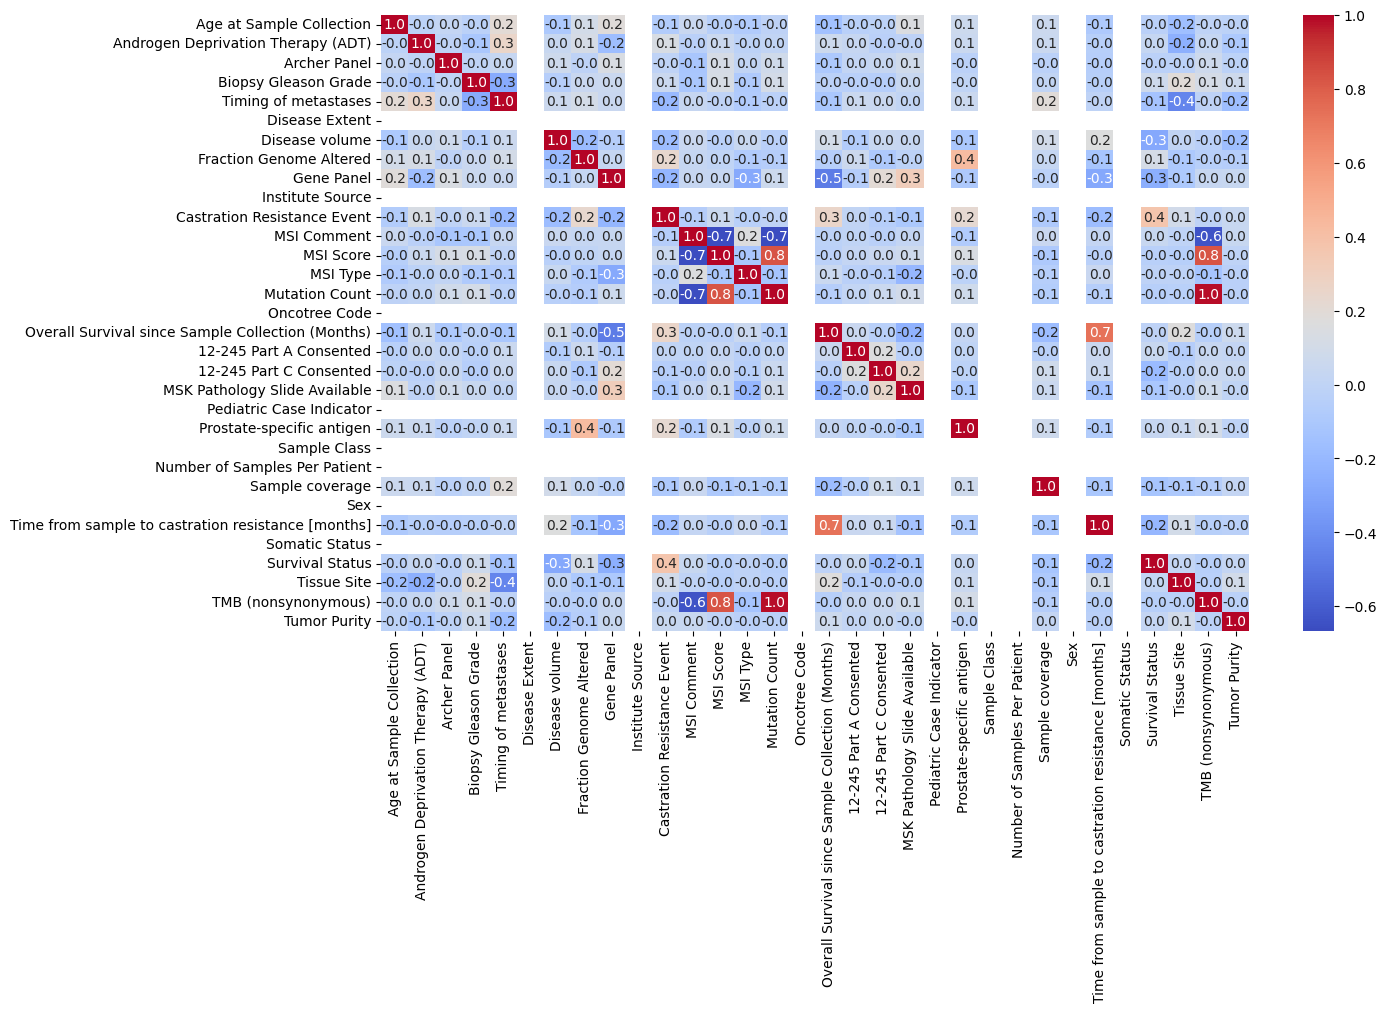

In [24]:
# corrlation
plt.figure(figsize=(14, 8))
sns.heatmap(corr,annot=True,fmt='.1f',cmap='coolwarm')

In [25]:
# split data into feature (x) and label (y)
x=data.drop(['Disease volume'],axis=1)
y=data['Disease volume']

In [26]:
x.head()

,Age at Sample Collection,Androgen Deprivation Therapy (ADT),Archer Panel,Biopsy Gleason Grade,Timing of metastases,Disease Extent,Fraction Genome Altered,Gene Panel,Institute Source,Castration Resistance Event,...,Sample Class,Number of Samples Per Patient,Sample coverage,Sex,Time from sample to castration resistance [months],Somatic Status,Survival Status,Tissue Site,TMB (nonsynonymous),Tumor Purity
0,10,0,0,3,0,0,0.0023,0,0,1,...,0,1,708,0,20.03,0,1,3,1.109155,6.0
1,12,1,0,2,0,0,0.1985,0,0,1,...,0,1,530,0,35.58,0,0,3,1.109155,11.0
2,22,0,0,2,0,0,0.1419,0,0,0,...,0,1,922,0,56.29,0,0,5,1.109155,90.0
3,19,1,0,3,0,0,0.0161,0,0,1,...,0,1,651,0,39.84,0,0,5,2.218311,21.0
4,12,1,0,3,0,0,0.3134,0,0,1,...,0,1,515,0,21.58,0,1,5,3.327466,32.0


In [27]:
y.head()

0    1
1    1
2    0
3    1
4    1
Name: Disease volume, dtype: int64

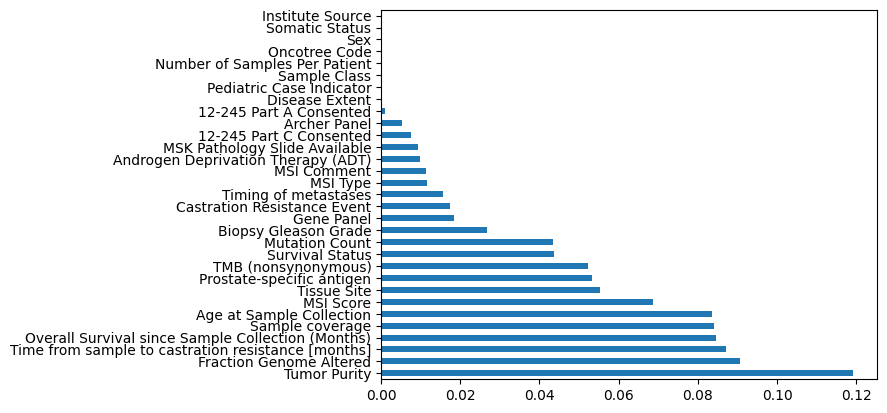

In [28]:
# plot feature importance
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier()
RF.fit(x,y)

feat_importances=pd.Series(RF.feature_importances_,index=x.columns)
feat_importances.nlargest(32).plot(kind='barh')
plt.show()

In [29]:
cols=x.columns

In [30]:
# Apply min max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [31]:
x=pd.DataFrame(x,columns=cols)

In [32]:
x.head()

,Age at Sample Collection,Androgen Deprivation Therapy (ADT),Archer Panel,Biopsy Gleason Grade,Timing of metastases,Disease Extent,Fraction Genome Altered,Gene Panel,Institute Source,Castration Resistance Event,...,Sample Class,Number of Samples Per Patient,Sample coverage,Sex,Time from sample to castration resistance [months],Somatic Status,Survival Status,Tissue Site,TMB (nonsynonymous),Tumor Purity
0,0.238095,0.0,0.0,0.6,0.0,0.0,0.003403,0.0,0.0,1.0,...,0.0,0.0,0.512278,0.0,0.156877,0.0,1.0,0.6,0.016878,0.000530
1,0.285714,1.0,0.0,0.4,0.0,0.0,0.293682,0.0,0.0,1.0,...,0.0,0.0,0.361558,0.0,0.278665,0.0,0.0,0.6,0.016878,0.000971
2,0.523810,0.0,0.0,0.4,0.0,0.0,0.209942,0.0,0.0,0.0,...,0.0,0.0,0.693480,0.0,0.440868,0.0,0.0,1.0,0.016878,0.007944
3,0.452381,1.0,0.0,0.6,0.0,0.0,0.023820,0.0,0.0,1.0,...,0.0,0.0,0.464014,0.0,0.312030,0.0,0.0,1.0,0.033755,0.001853
4,0.285714,1.0,0.0,0.6,0.0,0.0,0.463678,0.0,0.0,1.0,...,0.0,0.0,0.348857,0.0,0.169016,0.0,1.0,1.0,0.050633,0.002824


In [33]:
# Replace problematic characters in column names
x.columns = x.columns.str.replace(r'[\[\]<]', '', regex=True)

In [34]:
# splitting data into training and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,shuffle=True ,random_state = 40)

In [35]:
print("x train shape is : ",X_train.shape)
print("y train shape is : ",y_train.shape)

x train shape is :  (339, 31)
y train shape is :  (339,)


In [36]:
print("x test shape is : ",X_test.shape)
print("y test shape is : ",y_test.shape)

x test shape is :  (85, 31)
y test shape is :  (85,)


In [37]:
y_train.value_counts()

Disease volume
0    171
1    168
Name: count, dtype: int64

In [38]:
# oversampling of unbalanced data 
from imblearn.over_sampling import SMOTE
S=SMOTE(random_state=42)
X_train,y_train=S.fit_resample(X_train,y_train)

In [39]:
y_train.value_counts()

Disease volume
0    171
1    171
Name: count, dtype: int64

In [40]:
# Aplay Model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold

In [41]:
# Single Models
Single_models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier()
}

# Ensemble Models
ensemble_models = {
    'Random Forest': RandomForestClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier()
}

# Hyperparameter Grids 
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'KNN': {'n_neighbors': [3, 5, 7]},
    'Naive Bayes': {}, # Add an empty dictionary for Naive Bayes since it doesn't usually require hyperparameter tuning
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    'Decision Tree': {'max_depth': [None, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100, 200]},
    'Extra Trees': {'n_estimators': [50, 100, 200]},
    'Bagging': {'n_estimators': [10, 20, 30]},
    'AdaBoost': {'n_estimators': [50, 100, 200]},
    'Gradient Boosting': {'n_estimators': [50, 100, 200]},
    'XGBoost': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
}

In [42]:
# kfold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [43]:
# Model Evaluation and Selection on single model
best_model={}
for name , model in Single_models.items():
    grid=GridSearchCV(model,param_grids[name],cv=cv,scoring='accuracy')
    grid.fit(X_train,y_train)
    best_model[name]=grid.best_estimator_
    print('model name = ',name)
    print('Best Paramter = ',grid.best_params_)
    print('Best score = ',grid.best_score_)
    print('--'*20)

model name =  Logistic Regression
Best Paramter =  {'C': 10}
Best score =  0.6080136402387042
----------------------------------------
model name =  KNN
Best Paramter =  {'n_neighbors': 5}
Best score =  0.6198635976129583
----------------------------------------
model name =  Naive Bayes
Best Paramter =  {}
Best score =  0.6255754475703326
----------------------------------------
model name =  SVM
Best Paramter =  {'C': 10, 'kernel': 'rbf'}
Best score =  0.6371696504688831
----------------------------------------
model name =  Decision Tree
Best Paramter =  {'max_depth': 5}
Best score =  0.6721653878942881
----------------------------------------


In [44]:
# Model Evaluation and Selection on enesmble model
for name,model in ensemble_models.items():
    grid=GridSearchCV(model,param_grids[name],cv=cv,scoring='accuracy',error_score='raise')
    grid.fit(X_train,y_train)
    best_model[name]=grid.best_estimator_
    print('model name = ',name)
    print('Best Paramter = ',grid.best_params_)
    print('Best score = ',grid.best_score_)
    print('--'*20)

model name =  Random Forest
Best Paramter =  {'n_estimators': 200}
Best score =  0.7102301790281329
----------------------------------------
model name =  Extra Trees
Best Paramter =  {'n_estimators': 100}
Best score =  0.6694799658994033
----------------------------------------
model name =  Bagging
Best Paramter =  {'n_estimators': 30}
Best score =  0.7072890025575448
----------------------------------------
model name =  AdaBoost
Best Paramter =  {'n_estimators': 50}
Best score =  0.681457800511509
----------------------------------------
model name =  Gradient Boosting
Best Paramter =  {'n_estimators': 100}
Best score =  0.710613810741688
----------------------------------------
model name =  XGBoost
Best Paramter =  {'learning_rate': 0.01, 'n_estimators': 200}
Best score =  0.7191815856777494
----------------------------------------


In [45]:
best_model

{'Logistic Regression': LogisticRegression(C=10),
 'KNN': KNeighborsClassifier(),
 'Naive Bayes': GaussianNB(),
 'SVM': SVC(C=10),
 'Decision Tree': DecisionTreeClassifier(max_depth=5),
 'Random Forest': RandomForestClassifier(n_estimators=200),
 'Extra Trees': ExtraTreesClassifier(),
 'Bagging': BaggingClassifier(n_estimators=30),
 'AdaBoost': AdaBoostClassifier(),
 'Gradient Boosting': GradientBoostingClassifier(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.01, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
        

model name = Logistic Regression
accuracy score =  0.6470588235294118
classification_report =                precision    recall  f1-score   support

           0       0.66      0.60      0.62        42
           1       0.64      0.70      0.67        43

    accuracy                           0.65        85
   macro avg       0.65      0.65      0.65        85
weighted avg       0.65      0.65      0.65        85



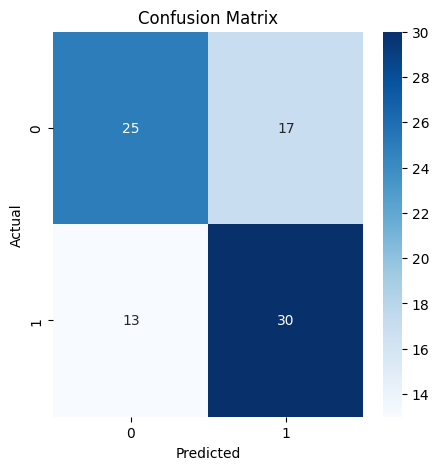

--------------------------------------------------------------------------------
model name = KNN
accuracy score =  0.6
classification_report =                precision    recall  f1-score   support

           0       0.59      0.62      0.60        42
           1       0.61      0.58      0.60        43

    accuracy                           0.60        85
   macro avg       0.60      0.60      0.60        85
weighted avg       0.60      0.60      0.60        85



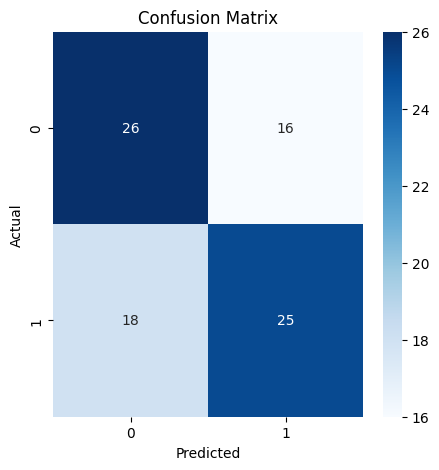

--------------------------------------------------------------------------------
model name = Naive Bayes
accuracy score =  0.6588235294117647
classification_report =                precision    recall  f1-score   support

           0       0.71      0.52      0.60        42
           1       0.63      0.79      0.70        43

    accuracy                           0.66        85
   macro avg       0.67      0.66      0.65        85
weighted avg       0.67      0.66      0.65        85



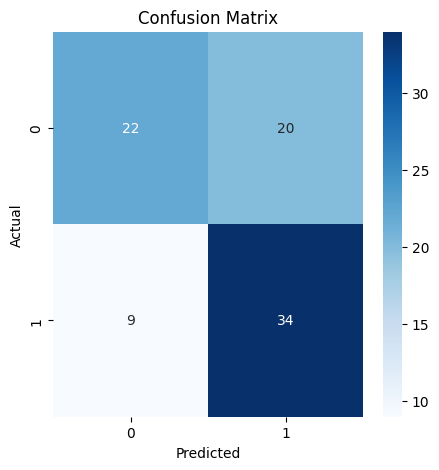

--------------------------------------------------------------------------------
model name = SVM
accuracy score =  0.611764705882353
classification_report =                precision    recall  f1-score   support

           0       0.60      0.67      0.63        42
           1       0.63      0.56      0.59        43

    accuracy                           0.61        85
   macro avg       0.61      0.61      0.61        85
weighted avg       0.61      0.61      0.61        85



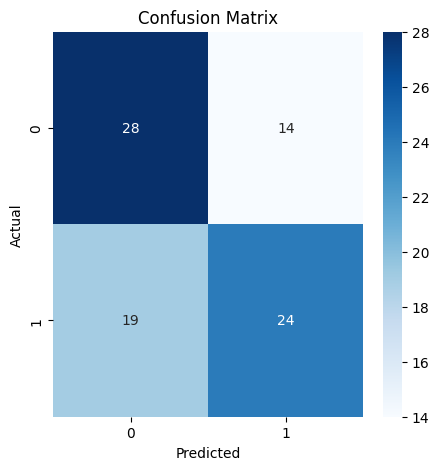

--------------------------------------------------------------------------------
model name = Decision Tree
accuracy score =  0.6470588235294118
classification_report =                precision    recall  f1-score   support

           0       0.67      0.57      0.62        42
           1       0.63      0.72      0.67        43

    accuracy                           0.65        85
   macro avg       0.65      0.65      0.64        85
weighted avg       0.65      0.65      0.64        85



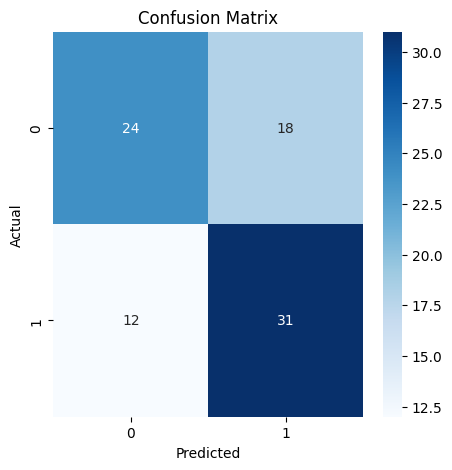

--------------------------------------------------------------------------------
model name = Random Forest
accuracy score =  0.6823529411764706
classification_report =                precision    recall  f1-score   support

           0       0.67      0.71      0.69        42
           1       0.70      0.65      0.67        43

    accuracy                           0.68        85
   macro avg       0.68      0.68      0.68        85
weighted avg       0.68      0.68      0.68        85



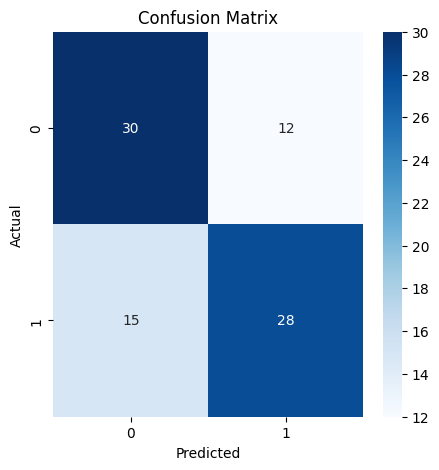

--------------------------------------------------------------------------------
model name = Extra Trees
accuracy score =  0.6705882352941176
classification_report =                precision    recall  f1-score   support

           0       0.66      0.69      0.67        42
           1       0.68      0.65      0.67        43

    accuracy                           0.67        85
   macro avg       0.67      0.67      0.67        85
weighted avg       0.67      0.67      0.67        85



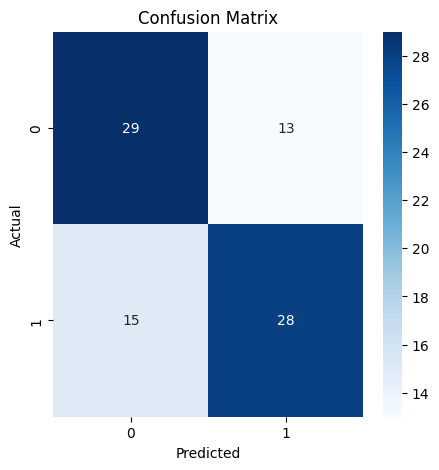

--------------------------------------------------------------------------------
model name = Bagging
accuracy score =  0.6588235294117647
classification_report =                precision    recall  f1-score   support

           0       0.65      0.67      0.66        42
           1       0.67      0.65      0.66        43

    accuracy                           0.66        85
   macro avg       0.66      0.66      0.66        85
weighted avg       0.66      0.66      0.66        85



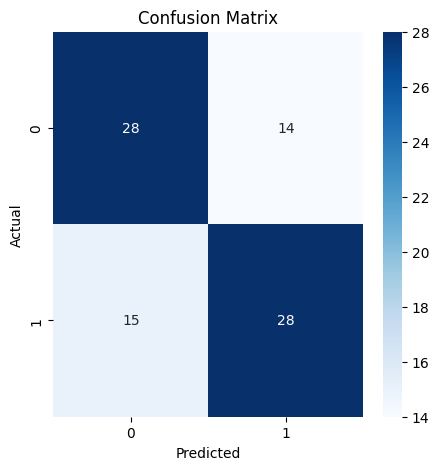

--------------------------------------------------------------------------------
model name = AdaBoost
accuracy score =  0.7529411764705882
classification_report =                precision    recall  f1-score   support

           0       0.76      0.74      0.75        42
           1       0.75      0.77      0.76        43

    accuracy                           0.75        85
   macro avg       0.75      0.75      0.75        85
weighted avg       0.75      0.75      0.75        85



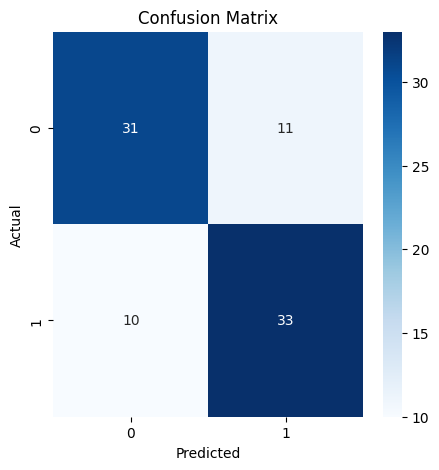

--------------------------------------------------------------------------------
model name = Gradient Boosting
accuracy score =  0.6588235294117647
classification_report =                precision    recall  f1-score   support

           0       0.64      0.69      0.67        42
           1       0.68      0.63      0.65        43

    accuracy                           0.66        85
   macro avg       0.66      0.66      0.66        85
weighted avg       0.66      0.66      0.66        85



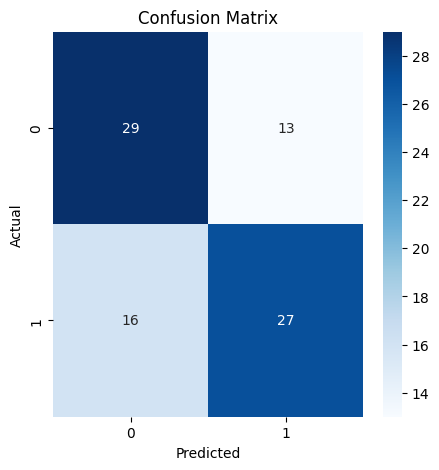

--------------------------------------------------------------------------------
model name = XGBoost
accuracy score =  0.6941176470588235
classification_report =                precision    recall  f1-score   support

           0       0.70      0.67      0.68        42
           1       0.69      0.72      0.70        43

    accuracy                           0.69        85
   macro avg       0.69      0.69      0.69        85
weighted avg       0.69      0.69      0.69        85



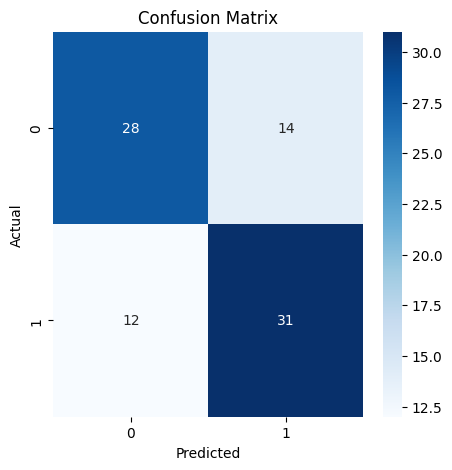

--------------------------------------------------------------------------------


In [46]:
# Evaluate Best Models on Test Set
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

for name,model in best_model.items():
    y_pred=model.predict(X_test)
    cm=confusion_matrix(y_test,y_pred)
    print("model name =",name)
    print('accuracy score = ',accuracy_score(y_test,y_pred))
    print('classification_report = ',classification_report(y_test,y_pred))
    # plot confusion_matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm,annot=True,fmt='.0f',cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    print("--"*40)